# 제조 AI 5주차


## STEP 0 

In [5]:
import os
import urllib.request
import zipfile

# C-MAPSS 데이터를 저장할 폴더 생성
DATA_DIR = './CMAPSSData'
os.makedirs(DATA_DIR, exist_ok=True)

# NASA 데이터 다운로드 주소
url = 'https://phm-datasets.s3.amazonaws.com/NASA/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip'

# 다운로드할 ZIP 파일 경로
outer_zip = os.path.join(DATA_DIR, 'CMAPSSData.zip')

# 1. NASA C-MAPSS 데이터 다운로드
urllib.request.urlretrieve(url, outer_zip)

# 2. 첫 번째 ZIP 파일 압축 해제
with zipfile.ZipFile(outer_zip, 'r') as z:
    z.extractall(DATA_DIR)

# 3. 내부에 포함된 CMAPSSData.zip 경로
inner_zip = os.path.join(
    DATA_DIR,
    '6. Turbofan Engine Degradation Simulation Data Set',
    'CMAPSSData.zip'
)

# 4. 내부 ZIP 파일을 CMAPSSData 폴더에 압축 해제
with zipfile.ZipFile(inner_zip, 'r') as z:
    z.extractall(DATA_DIR)

print('다운로드 및 압축 해제 완료')

다운로드 및 압축 해제 완료


```text
Manufacturing_AI_Project/
├── 제조AI_1주차.ipynb
├── 제조AI_5주차.ipynb
└── CMAPSSData
    ├── 6. Turbofan Engine Degradation Simulation Data Set
    ├── CMAPSSData.zip
    ├── Damage Propagation Modeling.pdf
    ├── readme.txt
    ├── RUL_FD001.txt
    ├── RUL_FD002.txt
    ├── RUL_FD003.txt
    ├── RUL_FD004.txt
    ├── test_FD001.txt
    ├── test_FD002.txt
    ├── test_FD003.txt
    ├── test_FD004.txt
    ├── train_FD001.txt
    ├── train_FD002.txt
    ├── train_FD003.txt
    └── train_FD004.txt
```

## STEP 1

In [26]:
import pandas as pd
import numpy as np
import koreanize_matplotlib
import matplotlib.pyplot as plt

# C-MAPSS 데이터가 저장된 폴더
DATA_DIR = './CMAPSSData'

# FD001 학습 데이터 파일 경로
train_path = f'{DATA_DIR}/train_FD001.txt'


# 데이터의 열 이름 정의
# unit  : 엔진 번호
# cycle : 엔진의 운전 사이클
# set1 ~ set3 : 운전 조건(Operating Settings)
# s1 ~ s21    : 21개의 센서 측정값
cols = (
    ['unit', 'cycle']
    + [f'set{i}' for i in range(1, 4)]
    + [f's{i}' for i in range(1, 22)]
)


# FD001 학습 데이터 불러오기
df = pd.read_csv(
    train_path,
    sep=r'\s+',      # 공백을 기준으로 데이터 구분
    header=None,     # 원본 파일에는 열 이름이 없음
    names=cols       # 위에서 정의한 열 이름 사용
)


# 데이터 크기 확인
print('데이터 크기:', df.shape)

# 전체 엔진 수 확인
print('엔진 수:', df['unit'].nunique())

# 데이터의 처음 5개 행 확인
df.head(10)

데이터 크기: (20631, 26)
엔진 수: 100


,unit,cycle,set1,set2,set3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: cycle, dtype: float64


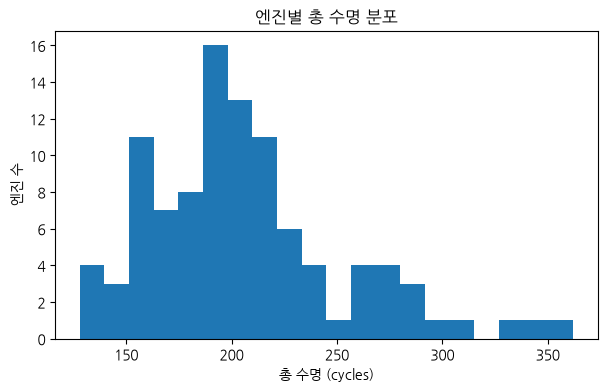

In [9]:
# 각 엔진의 총 수명 계산

# 엔진별로 가장 마지막 cycle을 해당 엔진의 총 수명으로 사용
life = df.groupby('unit')['cycle'].max()

# 엔진 수명의 기초 통계 확인
print(life.describe().round(1))

# 엔진별 총 수명 분포 시각화
plt.figure(figsize=(7, 4))
plt.hist(life, bins=20)
plt.xlabel('총 수명 (cycles)')
plt.ylabel('엔진 수')
plt.title('엔진별 총 수명 분포')
plt.show()

In [ ]:
# 각 시점에서 엔진의 잔여수명(RUL: Remaining Useful Life) 계산
# RUL = 엔진의 마지막 cycle - 현재 cycle
df['RUL'] = (
    df.groupby('unit')['cycle'].transform('max')
    - df['cycle']
)

# RUL의 최대값을 125로 제한
df['RUL'] = df['RUL'].clip(upper=125)


# 1번 엔진의 일부 시점에서 cycle과 RUL 확인
df[df['unit'] == 1][['cycle', 'RUL']].iloc[[0, 50, 100, -1]]

,cycle,RUL
0,1,125
50,51,125
100,101,91
191,192,0


In [11]:
# 사용할 센서 열 정의 (s1 ~ s21)
sensor_cols = [f's{i}' for i in range(1, 22)]


# 전체 100대의 엔진 중 1~80번 엔진을 학습 데이터로 사용
train_units = df['unit'].unique()[:80]

# 학습 엔진의 데이터만 선택
tr = df[df['unit'].isin(train_units)]


# 학습 데이터에서 각 센서의 표준편차 계산
std_tr = tr[sensor_cols].std()

# 표준편차가 거의 0인 센서(값의 변화가 없는 센서) 제거
use_cols = std_tr[std_tr > 1e-6].index.tolist()

print('사용 센서:', len(use_cols), '개')
print(use_cols)


# 학습 데이터에서 각 센서의 평균과 표준편차 계산
mu = tr[use_cols].mean()
sd = tr[use_cols].std()


# 원본 데이터를 복사하여 표준화
df_s = df.copy()

# 학습 데이터의 평균과 표준편차를 사용하여 전체 데이터 표준화
df_s[use_cols] = (df[use_cols] - mu) / sd


# 1~80번 엔진 → 학습 데이터
tr_s = df_s[df_s['unit'].isin(train_units)]

# 81~100번 엔진 → 검증 데이터
va_s = df_s[~df_s['unit'].isin(train_units)]

print('Train 엔진 수:', tr_s['unit'].nunique())
print('Validation 엔진 수:', va_s['unit'].nunique())

사용 센서: 15 개
['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Train 엔진 수: 80
Validation 엔진 수: 20


## STEP 2

In [13]:
# 윈도우 크기 설정
# 연속된 30 cycle의 센서 데이터를 하나의 학습 샘플로 사용
W = 30


# 시계열 데이터를 윈도우 형태로 변환하는 함수
def make_windows(data):

    Xs = []   # 센서 데이터
    ys = []   # RUL 정답

    # 엔진별로 데이터를 분리하여 처리
    for unit, group in data.groupby('unit'):
        # 해당 엔진의 센서 데이터
        sensor_data = group[use_cols].values
        # 해당 엔진의 RUL
        rul_data = group['RUL'].values
        # 30 cycle씩 이동하면서 윈도우 생성
        for i in range(len(group) - W + 1):
            # 연속된 30 cycle의 센서 데이터를 하나의 입력으로 저장
            Xs.append(sensor_data[i:i+W])
            # 윈도우의 마지막 시점에 해당하는 RUL을 정답으로 저장
            ys.append(rul_data[i+W-1])

    # NumPy 배열로 변환
    return (
        np.array(Xs, dtype='float32'),
        np.array(ys, dtype='float32')
    )


# Train 데이터 윈도잉
X_tr, y_tr = make_windows(tr_s)

# Validation 데이터 윈도잉
X_va, y_va = make_windows(va_s)


# 데이터 크기 확인
print('X_tr:', X_tr.shape)
print('y_tr:', y_tr.shape)

print('X_va:', X_va.shape)
print('y_va:', y_va.shape)

X_tr: (13818, 30, 15)
y_tr: (13818,)
X_va: (3913, 30, 15)
y_va: (3913,)


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# TensorFlow에서 사용 가능한 GPU 확인
print('GPU:', tf.config.list_physical_devices('GPU'))


# LSTM 기반 RUL 예측 모델 생성
model = models.Sequential([

    # 연속된 30 cycle의 센서 데이터를 입력받아 시계열 특징 추출
    # 입력 형태: (30 cycle, 센서 개수)
    layers.Input(shape=(W, len(use_cols))),
    layers.LSTM(64),

    # 과적합 방지를 위해 20%의 뉴런을 무작위로 비활성화
    layers.Dropout(0.2),

    # LSTM에서 추출한 특징을 이용하여 RUL 예측
    layers.Dense(32, activation='relu'),

    # 최종 RUL 값 하나를 출력
    # 회귀 문제이므로 별도의 활성화 함수 사용하지 않음
    layers.Dense(1)
])


# 모델 학습 방법 설정
model.compile(
    optimizer='adam',
    # 실제 RUL과 예측 RUL의 평균제곱오차(MSE)를 최소화
    loss='mse',
    # 평가 지표로 RMSE 사용
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)


# 모델 구조 확인
model.summary()

GPU: []


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# LSTM 모델 학습
history = model.fit(

    # 학습 데이터
    X_tr,
    y_tr,

    # 각 Epoch 종료 후 검증 데이터로 성능 평가
    validation_data=(X_va, y_va),

    # 전체 학습 데이터를 15번 반복하여 학습
    epochs=15,

    # 한 번에 256개의 샘플을 사용하여 가중치 업데이트
    batch_size=256
)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 7275.5645 - rmse: 85.2969 - val_loss: 6604.0972 - val_rmse: 81.2656
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4404.3770 - rmse: 66.3655 - val_loss: 3410.4463 - val_rmse: 58.3990
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1940.4001 - rmse: 44.0500 - val_loss: 1312.2114 - val_rmse: 36.2245
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 769.6746 - rmse: 27.7430 - val_loss: 580.3919 - val_rmse: 24.0913
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 439.0788 - rmse: 20.9542 - val_loss: 386.0906 - val_rmse: 19.6492
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 332.7908 - rmse: 18.2426 - val_loss: 319.7583 - val_rmse: 17.8818
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 273.4157 - rmse: 16.5353 - val_loss: 259.4930 - val_rmse: 16.1088
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 242.4640 - rmse: 15.5713 - val_loss: 240.8681 - val_rmse: 15

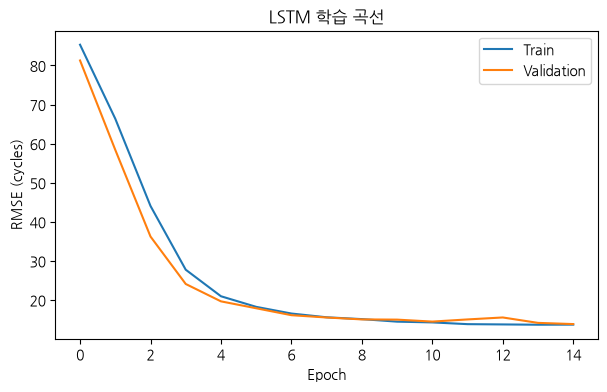

In [16]:
# 학습 과정에서 저장된 RMSE 변화 시각화
plt.figure(figsize=(7, 4))

# 학습 데이터의 RMSE
plt.plot(
    history.history['rmse'],
    label='Train'
)

# 검증 데이터의 RMSE
plt.plot(
    history.history['val_rmse'],
    label='Validation'
)

# 그래프 설정
plt.xlabel('Epoch')
plt.ylabel('RMSE (cycles)')
plt.title('LSTM 학습 곡선')
plt.legend()

plt.show()

## Step 3

검증 RMSE: 13.8 cycles


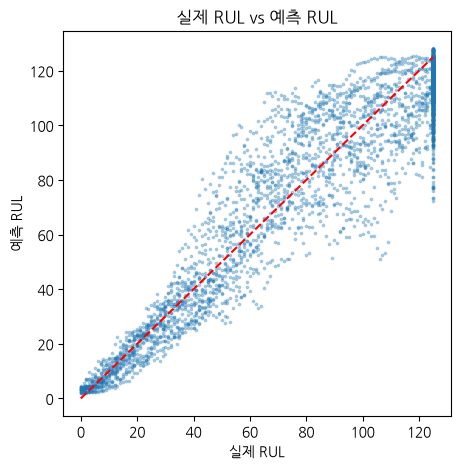

In [17]:
# 검증 데이터의 RUL 예측
pred = model.predict(
    X_va,
    verbose=0
).flatten()


# 검증 데이터의 RMSE 계산
rmse = np.sqrt(
    ((pred - y_va) ** 2).mean()
)

print(f'검증 RMSE: {rmse:.1f} cycles')


# 실제 RUL과 예측 RUL 비교
plt.figure(figsize=(5, 5))

plt.scatter(
    y_va,
    pred,
    s=3,
    alpha=0.3
)

# 실제값과 예측값이 동일한 기준선 (y = x)
plt.plot(
    [0, 125],
    [0, 125],
    'r--'
)

plt.xlabel('실제 RUL')
plt.ylabel('예측 RUL')
plt.title('실제 RUL vs 예측 RUL')

plt.show()

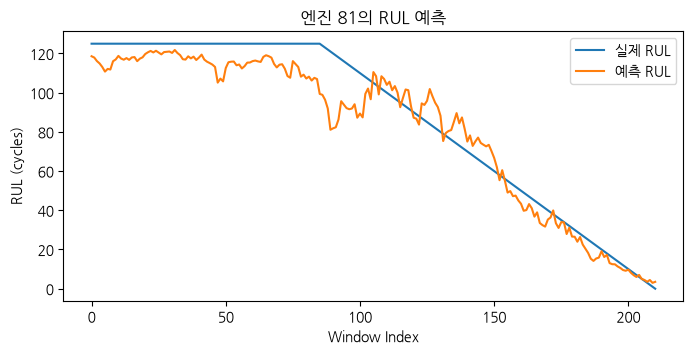

In [22]:
# 검증 데이터에서 첫 번째 엔진 선택
unit = va_s['unit'].unique()[0]

# 선택한 엔진의 데이터만 추출
engine_data = va_s[va_s['unit'] == unit]


# 선택한 엔진의 데이터를 30 cycle 윈도우로 변환
X_unit, y_unit = make_windows(engine_data)


# 각 시점의 RUL 예측
pred_unit = model.predict(
    X_unit,
    verbose=0
).flatten()


# 실제 RUL과 예측 RUL의 변화 시각화
plt.figure(figsize=(8, 3.5))

plt.plot(
    y_unit,
    label='실제 RUL'
)

plt.plot(
    pred_unit,
    label='예측 RUL'
)

plt.xlabel('Window Index')
plt.ylabel('RUL (cycles)')
plt.title(f'엔진 {unit}의 RUL 예측')

plt.legend()
plt.show()

In [23]:
# 검증 데이터의 예측 오차 계산
# 양수: RUL 과대 예측 / 음수: RUL 과소 예측
error = pred - y_va


# RUL 구간별로 RMSE 계산
for low, high in [(0, 30), (30, 70), (70, 126)]:

    # 해당 RUL 구간에 속하는 데이터 선택
    mask = (y_va >= low) & (y_va < high)

    # 해당 구간의 RMSE 계산
    rmse_range = np.sqrt(
        (error[mask] ** 2).mean()
    )

    # 결과 출력
    print(
        f'RUL {low:>3}~{high:<3}: '
        f'RMSE {rmse_range:.1f} cycles '
        f'({mask.sum()}개)'
    )

RUL   0~30 : RMSE 4.2 cycles (600개)
RUL  30~70 : RMSE 14.5 cycles (800개)
RUL  70~126: RMSE 15.1 cycles (2513개)


# 과제

### 1. Window Size에 따른 RUL 예측 성능 비교

| Window Size (W) | 검증 RMSE (cycles) | 말기 RMSE (RUL 0~30) | 비고 |
|:---:|:---:|:---:|:---:|
| **15** |  |  | 과제 |
| **30** |  |  | 수업 Baseline |
| **50** |  |  | 과제 |

### 2. XGBoost는 방법과의 비교 (선택)